### Simple Linear regression


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import train_test_split

In [17]:
X = np.array([[500],[800],[1000],[1200]])   #area
Y = np.array([20,30,40,50])                 #price

#Create and train model
#Fit means the model learns the slop and intercept from data
model =LinearRegression()
model.fit(X, Y)

model.predict([[900]])
#predict means using learned patterns to estimate new values


array([36.07476636])

### 📊 Multiple Linear Regression & Multicollinearity Analysis
### California Housing Dataset

### Objectives:
1. Build correlation heatmap to visualize relationships
2. Calculate VIF scores for all features
3. Identify multicollinearity issues
4. Understand impact on regression model


In [8]:
# Import required libraries (No seaborn!)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import sys
import subprocess

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style for better visuals
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 3.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 4.2 MB/s eta 0:00:00ta 0:00:01



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


✅ Libraries imported successfully!


In [10]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Display basic info
print("📋 Dataset Shape:", df.shape)
print("\n📊 First 5 rows:")
print(df.head())

print("\n📊 Data Types:")
print(df.dtypes)

print("\n📊 Basic Statistics:")
print(df.describe())

📋 Dataset Shape: (20640, 9)

📊 First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

📊 Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

📊 Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Populati

### 📖 Feature Descriptions

| Feature | Description | Unit |
|---------|-------------|------|
| MedInc | Median income in block | Tens of thousands |
| HouseAge | Median house age | Years |
| AveRooms | Average rooms per household | Number |
| AveBedrms | Average bedrooms per household | Number |
| Population | Block population | Count |
| AveOccup | Average household occupancy | Number |
| Latitude | Block latitude | Degrees |
| Longitude | Block longitude | Degrees |
| MedHouseVal | **Target: Median house value** | Hundreds of thousands |

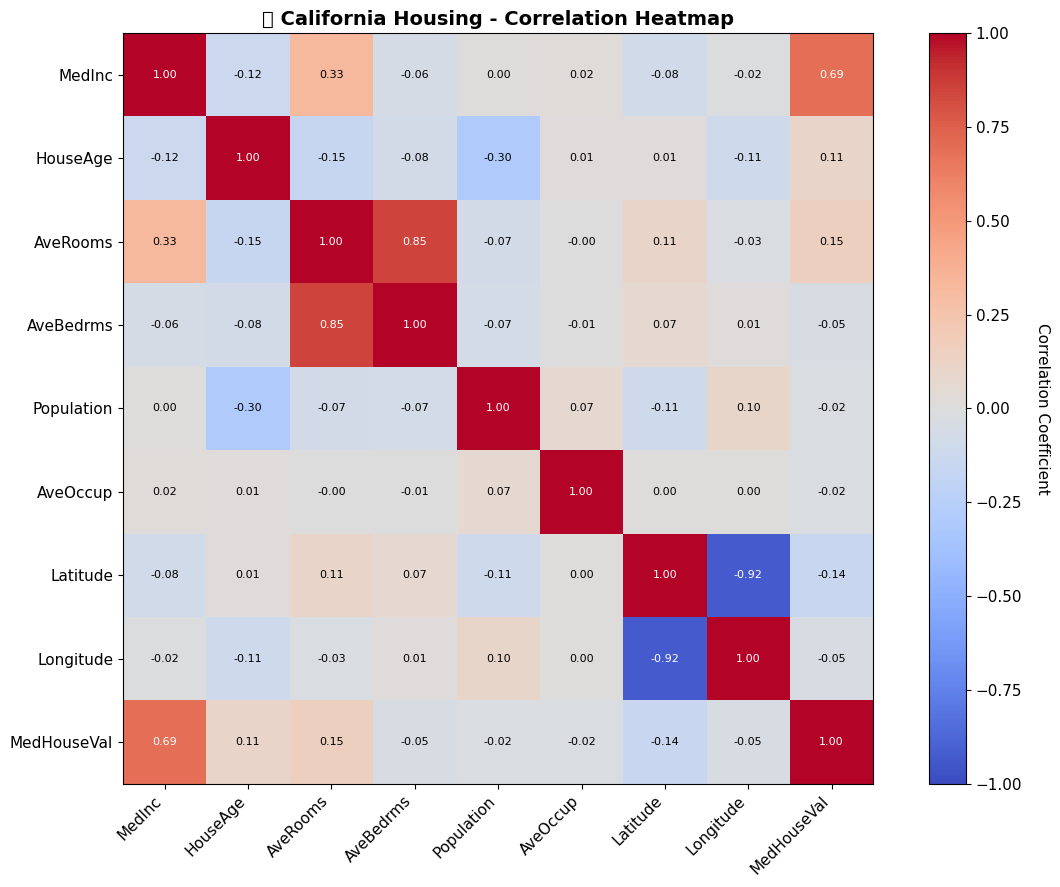


🔍 HIGHEST CORRELATIONS (|r| > 0.7):
  • AveRooms ↔ AveBedrms: 0.848
  • Latitude ↔ Longitude: -0.925

🎯 CORRELATIONS WITH TARGET (MedHouseVal):
  • MedHouseVal: 1.000
  • MedInc: 0.688
  • AveRooms: 0.152
  • HouseAge: 0.106
  • AveOccup: -0.024
  • Population: -0.025
  • Longitude: -0.046
  • AveBedrms: -0.047
  • Latitude: -0.144


In [13]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create custom heatmap using matplotlib
fig, ax = plt.subplots(figsize=(12, 9))

# Create a colored grid
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set ticks
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.columns)

# Add correlation values in each cell
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center",
                       color="white" if abs(correlation_matrix.iloc[i, j]) > 0.5 else "black",
                       fontsize=8)

ax.set_title('🏠 California Housing - Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print high correlations (more detailed)
print("\n🔍 HIGHEST CORRELATIONS (|r| > 0.7):")
print("="*50)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            print(f"  • {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr:.3f}")
            
# Also print with target variable
print("\n🎯 CORRELATIONS WITH TARGET (MedHouseVal):")
print("="*50)
target_corr = correlation_matrix['MedHouseVal'].sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"  • {feature}: {corr:.3f}")

In [15]:
# Simple function to calculate VIF
def calculate_vif(dataframe, feature_list):
    """Calculate VIF for each feature"""
    vif_values = []
    for i in range(len(feature_list)):
        vif = variance_inflation_factor(dataframe[feature_list].values, i)
        vif_values.append(vif)
    
    # Create result dataframe
    result = pd.DataFrame({
        'Feature': feature_list,
        'VIF': vif_values
    })
    return result.sort_values('VIF', ascending=False)

# Get all features (excluding Price)
all_features = df.columns[:-1]

# Calculate VIF
vif_results = calculate_vif(df, all_features)

# Display results clearly
print("="*50)
print("VIF (Variance Inflation Factor) Scores")
print("="*50)
print("VIF < 5  = ✅ Good")
print("VIF 5-10 = ⚠️  Moderate Problem")
print("VIF > 10 = 🔴 Severe Problem")
print("="*50)

for i, row in vif_results.iterrows():
    status = ""
    if row['VIF'] < 5:
        status = "✅ Good"
    elif row['VIF'] < 10:
        status = "⚠️ Moderate"
    else:
        status = "🔴 SEVERE"
    print(f"{row['Feature']:12} : {row['VIF']:8.2f}  {status}")

VIF (Variance Inflation Factor) Scores
VIF < 5  = ✅ Good
VIF 5-10 = ⚠️  Moderate Problem
VIF > 10 = 🔴 Severe Problem
Longitude    :   633.71  🔴 SEVERE
Latitude     :   559.87  🔴 SEVERE
AveRooms     :    45.99  🔴 SEVERE
AveBedrms    :    43.59  🔴 SEVERE
MedInc       :    11.51  🔴 SEVERE
HouseAge     :     7.20  ⚠️ Moderate
Population   :     2.94  ✅ Good
AveOccup     :     1.10  ✅ Good


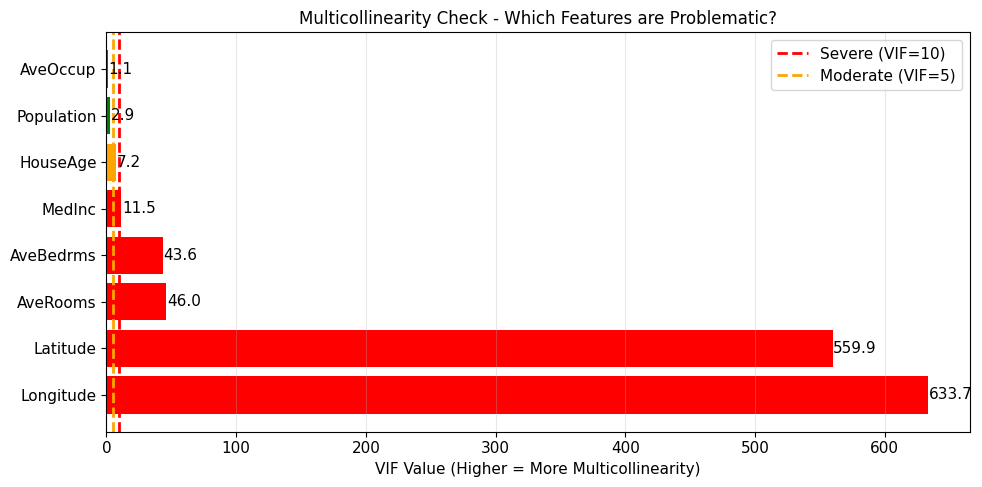


📌 Look for RED bars (VIF > 10) - these are problematic!


In [16]:
# Create simple bar chart
plt.figure(figsize=(10, 5))

# Create bars with different colors
colors = []
for vif in vif_results['VIF']:
    if vif >= 10:
        colors.append('red')
    elif vif >= 5:
        colors.append('orange')
    else:
        colors.append('green')

# Plot horizontal bars
plt.barh(vif_results['Feature'], vif_results['VIF'], color=colors)

# Add threshold lines
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Severe (VIF=10)')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Moderate (VIF=5)')

# Labels and title
plt.xlabel('VIF Value (Higher = More Multicollinearity)', fontsize=11)
plt.title('Multicollinearity Check - Which Features are Problematic?', fontsize=12)
plt.legend()
plt.grid(axis='x', alpha=0.3)

# Add values on bars
for i, vif in enumerate(vif_results['VIF']):
    plt.text(vif + 0.5, i, f'{vif:.1f}', va='center')

plt.tight_layout()
plt.show()

print("\n📌 Look for RED bars (VIF > 10) - these are problematic!")